# ⚡ Notebook 05: Proposed Model (LSTM + Attention)

**Project Title:** Email Intent Classification with Attention-Based Sequence Models and Priority Prediction  
**Phase Covered:** Phase 6 (Proposed Attention-Based Sequence Model)

---

### 🎯 Objectives & Intuition:
1. Implement a custom, beginner-friendly **Attention Layer** in Keras.
2. Why Attention? Standard LSTMs summarize an entire sequence into a single final state, which can lose focus on specific key words. Attention assigns a dynamic weight $\alpha_t$ to each word timestamp $h_t$, allowing the model to highlight crucial words (e.g., *"urgent"*, *"failed"*, *"refund"*).
3. Model Pipeline: Tokenized Input -> Embedding -> LSTM(return_sequences=True) -> SimpleAttention -> Dropout -> Dense -> Softmax.
4. Train with Early Stopping on validation loss.
5. Save model to `models/attention_model.keras`.
6. Plot training history and confusion matrix saved in `results/figures/`.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Layer
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")

@tf.keras.utils.register_keras_serializable(package="Custom")
class SimpleAttention(Layer):
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        score = tf.tanh(tf.matmul(inputs, self.W) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = tf.reduce_sum(inputs * attention_weights, axis=1)
        return context_vector


## 1. Load Data & Tokenized Sequences

In [2]:
train_df = pd.read_csv("../data/processed/train_emails.csv")
val_df = pd.read_csv("../data/processed/val_emails.csv")
test_df = pd.read_csv("../data/processed/test_emails.csv")

label_encoder = joblib.load("../models/label_encoder.pkl")
y_train = label_encoder.transform(train_df['intent'])
y_val = label_encoder.transform(val_df['intent'])
y_test = label_encoder.transform(test_df['intent'])

tokenizer = joblib.load("../models/tokenizer.pkl")
max_len = 30

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_email_text']), maxlen=max_len, padding='post', truncating='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_email_text']), maxlen=max_len, padding='post', truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_email_text']), maxlen=max_len, padding='post', truncating='post')


## 2. Build LSTM + Attention Architecture

In [3]:
num_classes = len(label_encoder.classes_)
max_words = 5000
embedding_dim = 64

inputs = Input(shape=(max_len,), name="email_input")
x = Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len, name="embedding")(inputs)
lstm_out = LSTM(64, return_sequences=True, name="lstm")(x)
context_vector = SimpleAttention(name="attention")(lstm_out)
x = Dropout(0.3, name="dropout_1")(context_vector)
x = Dense(64, activation='relu', name="dense_1")(x)
x = Dropout(0.3, name="dropout_2")(x)
outputs = Dense(num_classes, activation='softmax', name="intent_output")(x)

model = Model(inputs=inputs, outputs=outputs, name="LSTM_Attention_Model")
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


C:\Users\Vivek wadher\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Attention_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ email_input (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 30, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (SimpleAttention)     │ (None, 64)             │            94 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ intent_output (Dense)           │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 358,383 (1.37 MB)

 Trainable params: 358,383 (1.37 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Train Proposed Model

In [4]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=25,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

model.save("../models/attention_model.keras")


Epoch 1/25


 1/56 ━━━━━━━━━━━━━━━━━━━━ 1:29 2s/step - accuracy: 0.0938 - loss: 2.8327

 7/56 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0800 - loss: 2.8331

13/56 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0771 - loss: 2.8325

19/56 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0770 - loss: 2.8321 

...

35/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9854 - loss: 0.0929

42/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9849 - loss: 0.0946

48/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9844 - loss: 0.0967

54/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9838 - loss: 0.0988

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9836 - loss: 0.0997 - val_accuracy: 0.7526 - val_loss: 1.3244


## 4. Plot Training History

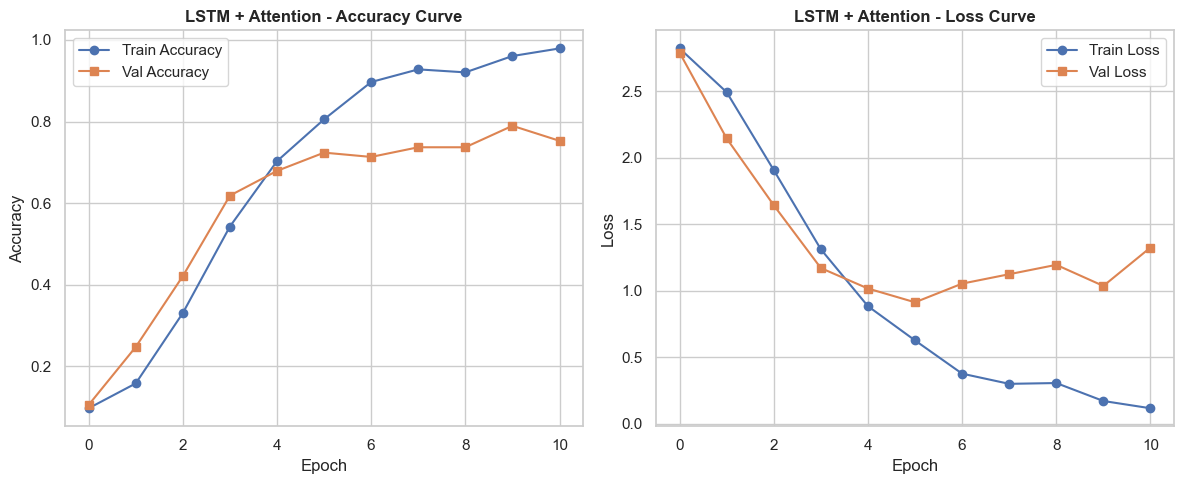

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('LSTM + Attention - Accuracy Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('LSTM + Attention - Loss Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("../results/figures/attention_training_history.png", dpi=300)
plt.show()


## 5. Evaluate Test Performance & Confusion Matrix

 1/12 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


Accuracy:           0.7447
Weighted Precision: 0.7617
Weighted Recall:    0.7447
Weighted F1-Score:  0.7445


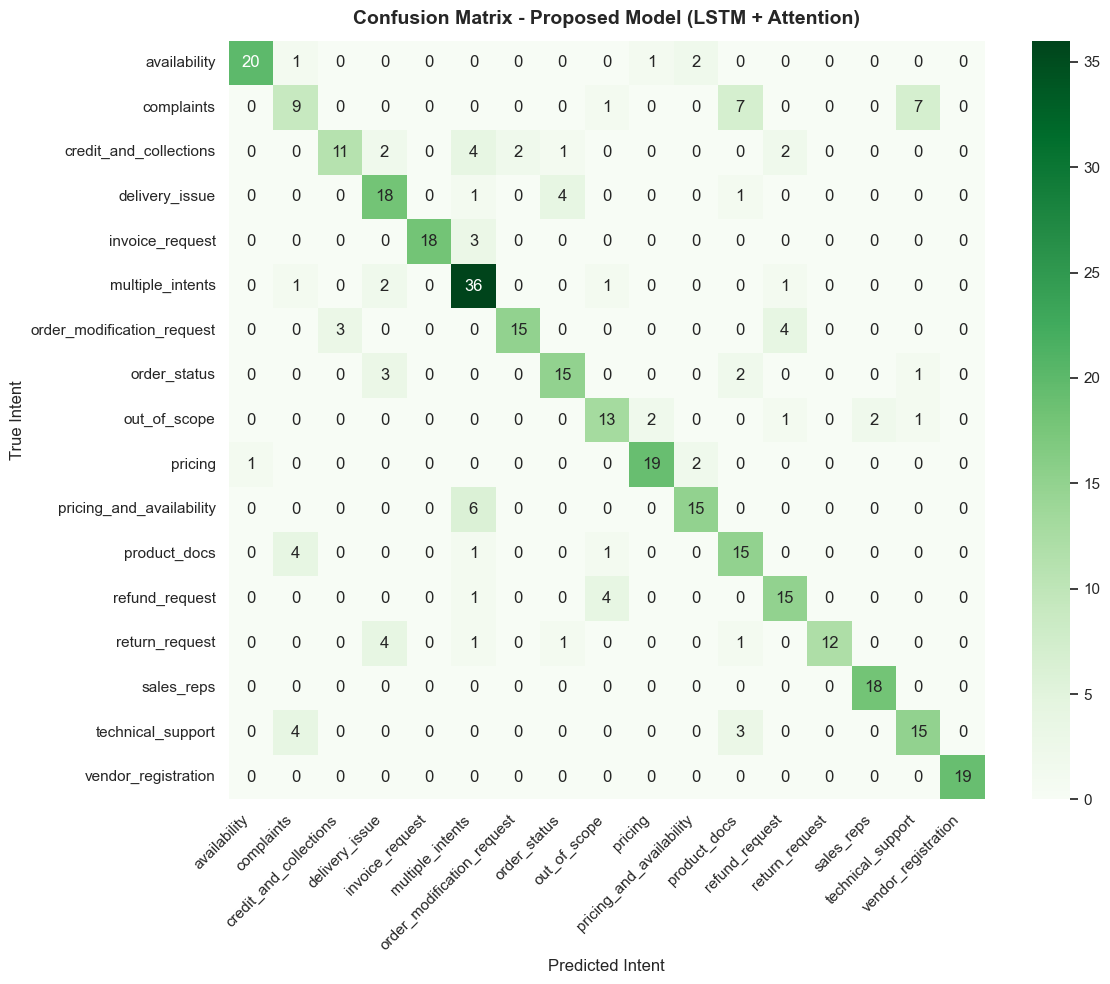

Attention metrics and plots saved successfully.


In [6]:
y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

print(f"Accuracy:           {acc:.4f}")
print(f"Weighted Precision: {prec_w:.4f}")
print(f"Weighted Recall:    {rec_w:.4f}")
print(f"Weighted F1-Score:  {f1_w:.4f}")

labels = list(label_encoder.classes_)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Proposed Model (LSTM + Attention)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/figures/attention_confusion_matrix.png", dpi=300)
plt.show()

metrics_df = pd.DataFrame([{
    'Model': 'LSTM + Attention',
    'Architecture': 'Embedding + LSTM + Simple Attention + Dense',
    'Accuracy': acc,
    'Precision': prec_w,
    'Recall': rec_w,
    'F1_Score': f1_w,
    'Macro_Precision': prec_m,
    'Macro_Recall': rec_m,
    'Macro_F1_Score': f1_m
}])
metrics_df.to_csv("../results/metrics/attention_metrics.csv", index=False)
print("Attention metrics and plots saved successfully.")
